In [ ]:
#Reference
#https://github.com/fnusatvik07/agent-builder-thinkinginglanggraph/blob/main/workbooks/07_prompt_chaining.ipynb

**Prompt chaining is the simplest workflow pattern. Each LLM call processes the output of the previous one. Sometimes you also drop in a non-LLM gate to short-circuit the chain**

```text
Example 1: Translation

Original Document
        ↓
Translate to English
        ↓
Verify meaning is preserved
        ↓
Final Translation
```

```text
Example 2: Writing

Topic
  ↓
Draft Article
  ↓
Improve Structure
  ↓
Polish Grammar & Tone
  ↓
Final Article
```


```text
Example 3: Coding

Requirement
     ↓
Generate Code
     ↓
Explain Code
     ↓
Write Unit Tests
```
every stage is different and depends on the previous stage
Why not one giant prompt?

Many people write:

"Generate code, explain it, write tests, optimize it, review it, and document it."

**Problems:**

Model may skip instructions

Steps get mixed together

Quality becomes inconsistent

Harder to debug

In [1]:
!pip install langchain langchain-groq langgraph python-dotenv ipython --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 18.6 MB/s eta 0:00:00


In [5]:
import os
from dotenv import load_dotenv
load_dotenv('/content/.env.txt')
print("Keys loaded:", "GROQ_API_KEY")


Keys loaded: GROQ_API_KEY


In [6]:
# Initialize Groq model
from langchain.chat_models import init_chat_model

In [7]:
llm = init_chat_model(
    "groq:llama-3.3-70b-versatile",
    temperature=0
)

print("LLM ready")

LLM ready


In [9]:
from typing import TypedDict

In [17]:
class State(TypedDict):
    topic: str
    joke: str
    improved_joke: str
    final_joke: str

def generate_joke(state: State):
    msg = llm.invoke(f"Write a short, one line joke about {state['topic']}")
    print(f"[generate] -> {msg.content[:80]}")
    return {"joke": msg.content}

'''
def check_punchline(state: State):
    """Gate: does the joke look like it has a punchline?"""
    if "?" in state["joke"] or "!" in state["joke"]:
        print("[gate] punchline present, skipping improve+polish")
        return "Pass"
    print("[gate] no punchline, continuing to improve")
    return "Fail"
'''
'''
#LLM As Judge
def check_punchline(state: State):
    prompt = f"""
    Determine whether this joke contains both:
    1. A setup
    2. A punchline

    Joke:
    {state['joke']}

    Return only:
    Pass
    or
    Fail
    """

    result = llm.invoke(prompt).content.strip()

    return "Pass" if "Pass" in result else "Fail"
    '''
from typing import Literal
from pydantic import BaseModel

class JokeEvaluation(BaseModel):
    verdict: Literal["Pass", "Fail"]
    reasoning: str

structured_llm = llm.with_structured_output(JokeEvaluation)

def check_punchline(state: State):
    result = structured_llm.invoke(
        f"""
        Evaluate this joke.

        Joke:
        {state['joke']}

        Does it contain both a setup and a punchline?
        """
    )

    print(f"[judge] {result.reasoning}")

    return result.verdict



def improve_joke(state: State):
    msg = llm.invoke(f"Make this joke funnier by adding wordplay: {state['joke']}")
    print(f"[improve] -> {msg.content[:80]}")
    return {"improved_joke": msg.content}

def polish_joke(state: State):
    msg = llm.invoke(f"Add a surprising twist to this joke: {state['improved_joke']}")
    print(f"[polish] -> {msg.content[:80]}")
    return {"final_joke": msg.content}


**Build the graph (stepwise style)**

In [18]:
from langgraph.graph import StateGraph, START, END

In [19]:
builder = StateGraph(State)

builder.add_node("generate_joke", generate_joke)
builder.add_node("improve_joke", improve_joke)
builder.add_node("polish_joke", polish_joke)

builder.add_edge(START, "generate_joke")

builder.add_conditional_edges(
    "generate_joke", check_punchline, {"Fail": "improve_joke", "Pass": END}
)

builder.add_edge("improve_joke", "polish_joke")
builder.add_edge("polish_joke", END)

chain = builder.compile()

**a-Display in Cell**

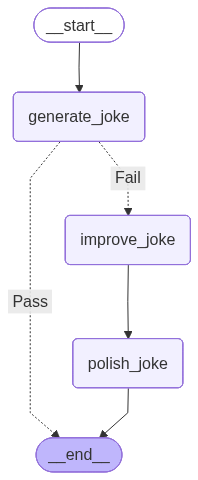

In [21]:
from IPython.display import Image, display

display(Image(chain.get_graph().draw_mermaid_png()))

**b-save and display easy but not safe**

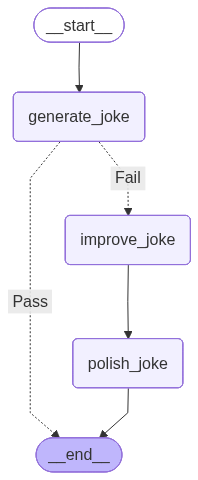

In [29]:
from pathlib import Path
from IPython.display import Image, display

Path("graph1.png").write_bytes(
    chain.get_graph().draw_mermaid_png()
)

display(Image(filename="graph.png"))

**c-More Safe Style**

In [34]:
from pathlib import Path
from IPython.display import Image, display, Markdown

def save_show_graph(app, name="graph_errorhandling_mmdbackup"):
    # Save Mermaid source
    Path(f"{name}.mmd").write_text(
        chain.get_graph().draw_mermaid()
    )

    try:
        # Save PNG
        Path(f"{name}.png").write_bytes(
            chain.get_graph().draw_mermaid_png()
        )

        # Display if saved successfully
        if Path(f"{name}.png").exists():
            display(Image(filename=f"{name}.png"))

    except Exception as e:
        display(
            Markdown(
                f"PNG generation failed: {e}<br>"
                f"Open <b>{name}.mmd</b> in Mermaid Live."
            )
        )

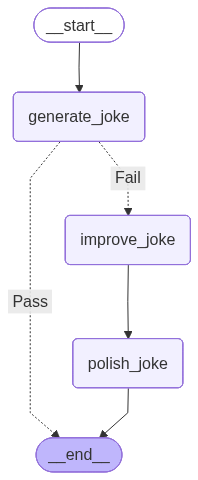

In [35]:
save_show_graph(chain, "07_prompt_chain")

In [37]:
state = chain.invoke({"topic": "cats", "joke": "", "improved_joke": "", "final_joke": ""})

print("\n=== INITIAL JOKE ===\n", state["joke"])

if state.get("improved_joke"):
    print("\n=== IMPROVED ===\n", state["improved_joke"])
    print("\n=== FINAL ===\n", state["final_joke"])
else:
    print("\n(gate passed on the first try, no improve/polish)")

[generate] -> Why did the cat join a band, because it wanted to be the purr-cussionist.
[judge] The joke contains both a setup (Why did the cat join a band) and a punchline (because it wanted to be the purr-cussionist), making it a complete joke.

=== INITIAL JOKE ===
 Why did the cat join a band, because it wanted to be the purr-cussionist.

(gate passed on the first try, no improve/polish)


Same graph, chained builder
**Some teams prefer the compact form.** Same compiled graph, same output.

In [40]:
chain_b = (
    StateGraph(State)
    .add_node("generate_joke", generate_joke)
    .add_node("improve_joke", improve_joke)
    .add_node("polish_joke", polish_joke)
    .add_edge(START, "generate_joke")
    .add_conditional_edges("generate_joke", check_punchline, {"Fail": "improve_joke", "Pass": END})
    .add_edge("improve_joke", "polish_joke")
    .add_edge("polish_joke", END)
    .compile()
)
print("chained builder compiled, same graph as above")

chained builder compiled, same graph as above


**3. Functional API implementation**

The Functional API lets you express the same workflow as plain Python control flow. You decorate the LLM steps with @task and the whole pipeline with @entrypoint(). Each task still becomes a node under the hood, so durability and streaming still work.

In [41]:
from langgraph.func import entrypoint, task

@task
def generate_joke_t(topic: str):
    return llm.invoke(f"Write a short joke about {topic}").content

def check_punchline_t(joke: str):
    return "Pass" if ("?" in joke or "!" in joke) else "Fail"

@task
def improve_joke_t(joke: str):
    return llm.invoke(f"Make this joke funnier by adding wordplay: {joke}").content

@task
def polish_joke_t(joke: str):
    return llm.invoke(f"Add a surprising twist to this joke: {joke}").content

@entrypoint()
def prompt_chaining_workflow(topic: str):
    original = generate_joke_t(topic).result()
    if check_punchline_t(original) == "Pass":
        return original
    improved = improve_joke_t(original).result()
    return polish_joke_t(improved).result()

for step in prompt_chaining_workflow.stream("cats", stream_mode="updates"):
    print(step)


{'generate_joke_t': 'Why did the cat join a band? Because it wanted to be the purr-cussionist.'}
{'prompt_chaining_workflow': 'Why did the cat join a band? Because it wanted to be the purr-cussionist.'}


**Production Style, LLM as Judge with Structured Output**

In [42]:
from typing import Literal
from pydantic import BaseModel
from langgraph.func import task, entrypoint

class Evaluation(BaseModel):
    verdict: Literal["Pass", "Fail"]
    reasoning: str

judge_llm = llm.with_structured_output(Evaluation)


@task
def generate(topic):
    return llm.invoke(
        f"Write a short joke about {topic}"
    ).content


@task
def judge(joke: str):
    result = judge_llm.invoke(    #with structure Output
        f"""
        Does this joke contain both
        a setup and a punchline?

        Joke:
        {joke}
        """
    )

    print(f"[judge] {result.reasoning}")

    return result


@task
def improve(joke):
    return llm.invoke(
        f"Make this joke funnier: {joke}"
    ).content


@task
def polish(joke):
    return llm.invoke(
        f"Add a surprising twist: {joke}"
    ).content


@entrypoint()
def workflow(topic):
    joke = generate(topic).result()

    if judge(joke).result() == "Pass":
        return joke

    improved = improve(joke).result()

    return polish(improved).result()

In [45]:
for step in prompt_chaining_workflow.stream("Artificial Inteligence in 2026", stream_mode="updates"):
    print(step)

{'generate_joke_t': 'Why did the AI program in 2026 go to therapy? Because it was struggling to process its emotions and was feeling a little "glitchy" – but in the end, it just needed to reboot its self-esteem.'}
{'prompt_chaining_workflow': 'Why did the AI program in 2026 go to therapy? Because it was struggling to process its emotions and was feeling a little "glitchy" – but in the end, it just needed to reboot its self-esteem.'}


**Most real-world agent systems eventually use Graph API, while Functional API is excellent for straightforward sequential workflows.**